# Sentinel_AI – Fraud Detection Model Explanation
## Understanding the data, model, and evaluation metrics

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve
from src.data import generate_fraud_data, preprocess_data
from src.features import engineer_features

%matplotlib inline

In [2]:
os.makedirs("images", exist_ok=True)

## 1. Load Data and Show Class Imbalance

Fraud rate: 13.32%


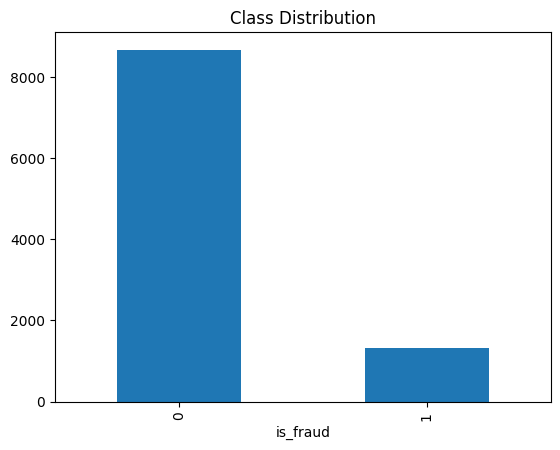

In [6]:
df = generate_fraud_data(10000)
print("Fraud rate: {:.2%}".format(df['is_fraud'].mean()))
df['is_fraud'].value_counts().plot(kind='bar', title='Class Distribution')
plt.savefig("images/class_distributions.png", bbox_inches='tight')
plt.show()

## 2. Visualize Feature Distributions

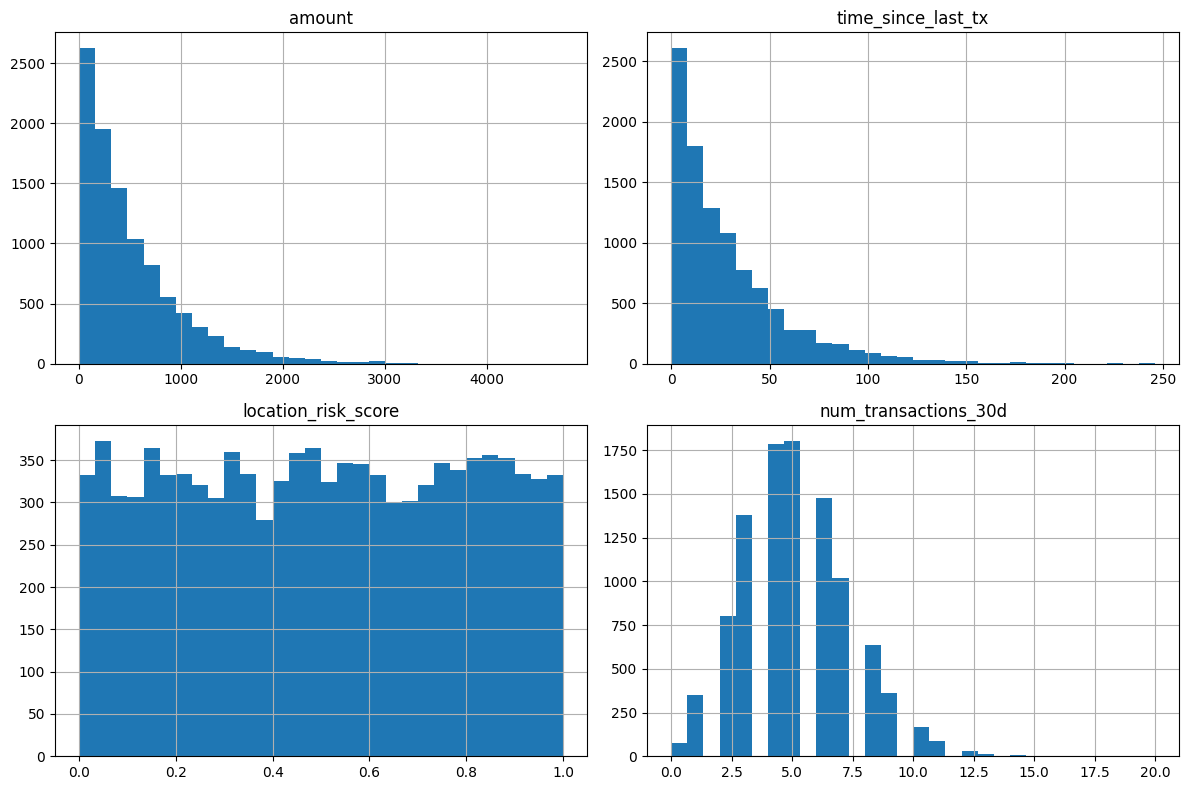

In [9]:
features = ['amount', 'time_since_last_tx', 'location_risk_score', 'num_transactions_30d']
df[features].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.savefig("images/feature_histograms.png", bbox_inches='tight')
plt.show()

## 3. Train a Simple RandomForest and Show Feature Importance

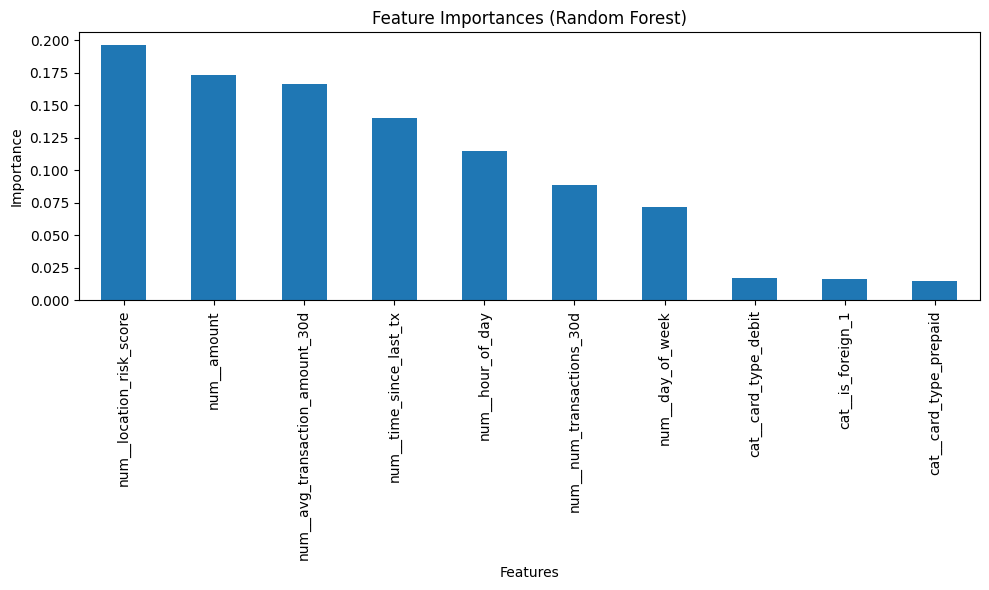

Top 5 most important features:
num__location_risk_score           0.196382
num__amount                        0.173267
num__avg_transaction_amount_30d    0.166404
num__time_since_last_tx            0.139918
num__hour_of_day                   0.115039
dtype: float64


In [12]:
# Generate or load data (using synthetic data for demo)
df = generate_fraud_data(10000)

# Apply feature engineering (same config as training)
df = engineer_features(df, config={'velocity': False, 'z_score': True, 'rolling_fraud': False})

# Preprocess the data
X_train, X_test, y_train, y_test, preprocessor = preprocess_data(df)

# Train RandomForest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Get feature names after preprocessing (includes one-hot encoded names)
feature_names_encoded = preprocessor.get_feature_names_out()
importances = model.feature_importances_

# Create a Series and sort
feat_imp = pd.Series(importances, index=feature_names_encoded).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig("images/feature_importances.png", bbox_inches='tight')
plt.show()

# Optional: print top 5 features
print("Top 5 most important features:")
print(feat_imp.head(5))

## 4. Explain ROC‑AUC and Average Precision

ROC-AUC: 0.547
Average Precision: 0.161


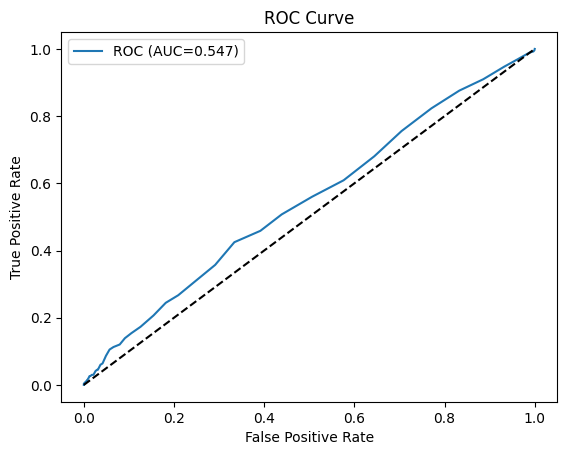

In [11]:
y_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.3f}")
print(f"Average Precision: {ap:.3f}")

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'ROC (AUC={auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig("images/roc_curve.png", bbox_inches='tight')
plt.show()

## 5. How to Use the Model for Predictions

In [ ]:
# Example: predict on first 5 test samples
sample = X_test[:5]
probs = model.predict_proba(sample)[:, 1]
print("Fraud probabilities:", probs)

# Choose threshold (e.g., 0.5)
threshold = 0.5
flags = (probs >= threshold).astype(int)
print("Flag as fraud:", flags)